# Task 2 — Product Category Clustering

**Goal:** group the products into 4–6 meta-categories with unsupervised learning, then give each group a readable name.

**Approach**
1. Clean the product names (some rows have two products glued together with `,,,`).
2. Build **one text per product** from what the product *is*: its clean name + its category tags.
3. Turn that text into vectors with a **sentence-transformer** (it knows "Fire HD 8 tablet" ≈ "Fire 7 tablet").
4. Choose k with **silhouette scores**, fit KMeans, inspect **every** product per cluster, then name the clusters.
5. Map the category back to every review and save `reviews_clustered.csv` for Task 3.

**Why not average the review embeddings?** Almost every review says "great, easy, love it, bought for my kids".
Averaged over thousands of reviews, every product's vector looks the same, so clusters follow review tone instead of product type.
GloVe also reads "fire" as flames and "echo" as a sound.

*Roman Urdu: Product ko uske naam aur categories se describe karo, reviews ke average se nahi.*

In [2]:
import sys
sys.path.append("..")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

from src import config, preprocessing

RANDOM_STATE = 42
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Step 1. Load the cleaned reviews
Output of notebook 01. Rows without a product name were already dropped there.

In [3]:
reviews = preprocessing.load_pre_processed()
print(reviews.shape)
reviews.head(3)

(27863, 5)


,name,categories,reviews.rating,reviews.text,reviews.title
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.


## Step 2. Clean the product names
Some names are two products glued together, e.g. `"Echo (Black),,,\r\nAmazon 9W PowerFast Charger,,,"`.
Keep the first product only, and tidy the spaces. This cleaned name is the product key (not `id`).

In [4]:
def clean_product_name(name):
    """Keep the first product when two names are glued together with 2+ commas."""
    if not isinstance(name, str):
        return None
    first = re.split(r",{2,}", name)[0]            # keep the first product
    first = re.sub(r"\s+", " ", first)               # \r\n and double spaces -> one space
    return first.strip(" ,") or None

reviews["product"] = reviews["name"].map(clean_product_name)

print("Raw names:    ", reviews["name"].nunique())
print("Clean products:", reviews["product"].nunique())

# See what changed
changed = reviews.loc[reviews["name"] != reviews["product"], ["name", "product"]].drop_duplicates()
changed.head(10)

Raw names:     48
Clean products: 40


,name,product
2814,Kindle Oasis E-reader with Leather Charging Co...,Kindle Oasis E-reader with Leather Charging Co...
2881,"Amazon Kindle Lighted Leather Cover,,,\r\nAmaz...",Amazon Kindle Lighted Leather Cover
2883,"Amazon Kindle Lighted Leather Cover,,,\r\nKind...",Amazon Kindle Lighted Leather Cover
2884,"Kindle Keyboard,,,\r\nKindle Keyboard,,,",Kindle Keyboard
3032,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...","Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ..."
3046,Amazon 5W USB Official OEM Charger and Power A...,Amazon 5W USB Official OEM Charger and Power A...
3245,"All-New Kindle E-reader - Black, 6 Glare-Free ...","All-New Kindle E-reader - Black, 6 Glare-Free ..."
3457,"Amazon Kindle Fire Hd (3rd Generation) 8gb,,,\...",Amazon Kindle Fire Hd (3rd Generation) 8gb
14421,Kindle Oasis E-reader with Leather Charging Co...,Kindle Oasis E-reader with Leather Charging Co...
14427,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Bl...,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black


## Step 3. One row per product
Clustering ~40 products is cleaner than clustering ~28k single reviews.
The text for each product = clean name + its unique category tags.

In [5]:
def unique_tags(category_strings):
    """Merge all category strings of a product into one list of unique tags."""
    tags = []
    for s in category_strings.dropna():
        for t in str(s).split(","):
            t = t.strip()
            if t and t not in tags:
                tags.append(t)
    return ", ".join(tags)

print(reviews["categories"])
print(unique_tags(reviews["categories"]))
products = (
    reviews.groupby("product")
    .agg(
        categories=("categories", unique_tags),
        n_reviews=("reviews.text", "size"),
        avg_rating=("reviews.rating", "mean"),
    )
    .reset_index()
)

#print(reviews[products])
products.info()
products["doc"] = products["product"] + ". Categories: " + products["categories"]

print(products.shape)
products.sort_values("n_reviews", ascending=False).head(10)

0        Electronics,iPad & Tablets,All Tablets,Fire Ta...
1        Electronics,iPad & Tablets,All Tablets,Fire Ta...
2        Electronics,iPad & Tablets,All Tablets,Fire Ta...
3        Electronics,iPad & Tablets,All Tablets,Fire Ta...
4        Electronics,iPad & Tablets,All Tablets,Fire Ta...
                               ...                        
27858    Stereos,Remote Controls,Amazon Echo,Audio Dock...
27859    Stereos,Remote Controls,Amazon Echo,Audio Dock...
27860    Stereos,Remote Controls,Amazon Echo,Audio Dock...
27861    Stereos,Remote Controls,Amazon Echo,Audio Dock...
27862    Stereos,Remote Controls,Amazon Echo,Audio Dock...
Name: categories, Length: 27863, dtype: object
Electronics, iPad & Tablets, All Tablets, Fire Tablets, Tablets, Computers & Tablets, eBook Readers, Kindle E-readers, E-Readers & Accessories, E-Readers, eBook Readers & Accessories, Covers, Kindle Store, Amazon Device Accessories, Kindle E-Reader Accessories, Kindle (5th Generation) Accessories, Kindl

,product,categories,n_reviews,avg_rating,doc
31,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Electronics, iPad & Tablets, All Tablets, Comp...",10962,4.453293,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes..."
26,Echo (White),"Fire Tablets, Tablets, Computers & Tablets, Al...",3308,4.645405,"Echo (White). Categories: Fire Tablets, Tablet..."
17,Amazon Kindle Paperwhite - eBook reader - 4 GB...,"Tablets, Fire Tablets, Computers & Tablets, Al...",3176,4.755038,Amazon Kindle Paperwhite - eBook reader - 4 GB...
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics, iPad & Tablets, All Tablets, Fire...",2814,4.586709,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
13,Amazon Fire Tv,"Stereos, Remote Controls, Amazon Echo, Audio D...",2527,4.650178,"Amazon Fire Tv. Categories: Stereos, Remote Co..."
29,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...","Computers/Tablets & Networking, Tablets & eBoo...",1685,4.510386,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16..."
20,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,"Fire Tablets, Tablets, Computers & Tablets, Al...",1033,4.550823,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...
38,"Kindle Voyage E-reader, 6 High-Resolution Disp...","Walmart for Business, Office Electronics, Tabl...",580,4.743103,"Kindle Voyage E-reader, 6 High-Resolution Disp..."
30,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Walmart for Business, Office Electronics, Tabl...",368,4.600543,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes..."
3,Amazon - Amazon Tap Portable Bluetooth and Wi-...,"Stereos, Remote Controls, Amazon Echo, Audio D...",318,4.729560,Amazon - Amazon Tap Portable Bluetooth and Wi-...


## Step 4. Turn each product into a vector
`all-MiniLM-L6-v2` is a small sentence-transformer (384 numbers per text) that understands meaning.
`normalize_embeddings=True` puts every vector at length 1, so KMeans compares direction (cosine-like), not size.

If the import fails: `pip install sentence-transformers` in your venv, then restart the kernel.

In [6]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("all-MiniLM-L6-v2")
X = encoder.encode(products["doc"].tolist(), normalize_embeddings=True, show_progress_bar=True)

print(X.shape)
print("Any NaN?", np.isnan(X).any())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

(40, 384)
Any NaN? False


## Step 5. Choose k
Try k = 2–8 but pick from **4–6** (the brief). Look at three things:
- **Silhouette** (higher = clusters are better separated),
- **Inertia / elbow** (where the curve bends),
- **Cluster sizes** (a cluster with 1 product is a warning sign).

,k,silhouette,inertia,sizes
0,2,0.188,11.95,"[28, 12]"
1,3,0.197,10.19,"[18, 12, 10]"
2,4,0.201,9.16,"[14, 12, 8, 6]"
3,5,0.193,8.36,"[12, 11, 7, 6, 4]"
4,6,0.209,7.64,"[12, 11, 6, 4, 4, 3]"
5,7,0.213,6.96,"[12, 9, 5, 4, 4, 3, 3]"
6,8,0.226,6.53,"[12, 9, 4, 4, 3, 3, 3, 2]"


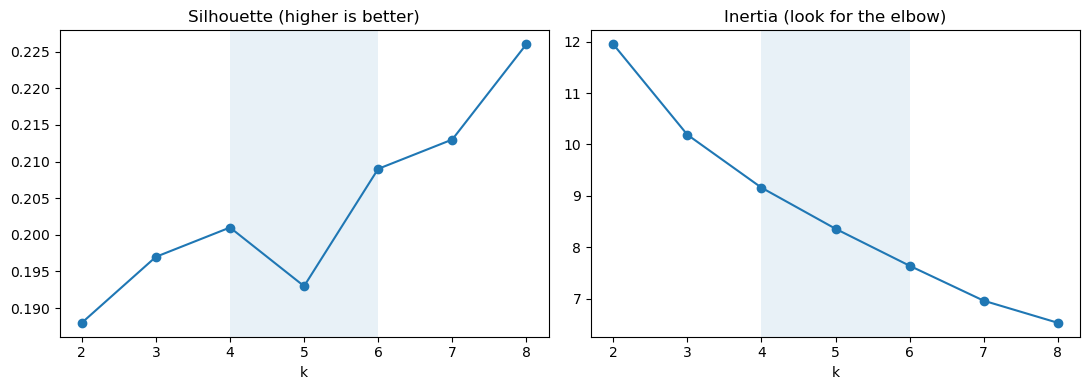

In [7]:
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X)
    rows.append({
        "k": k,
        "silhouette": round(silhouette_score(X, km.labels_), 3),
        "inertia": round(km.inertia_, 2),
        "sizes": sorted(np.bincount(km.labels_).tolist(), reverse=True),
    })
k_scores = pd.DataFrame(rows)
display(k_scores)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_scores["k"], k_scores["silhouette"], marker="o")
axes[0].set(title="Silhouette (higher is better)", xlabel="k")
axes[1].plot(k_scores["k"], k_scores["inertia"], marker="o")
axes[1].set(title="Inertia (look for the elbow)", xlabel="k")
for ax in axes:
    ax.axvspan(4, 6, alpha=0.1)   # the 4-6 range from the brief
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "clustering_choose_k.png", dpi=150)
plt.show()

## Step 6. Fit the final model
**Set `K` after reading Step 5**, and write one sentence on why.

In [8]:
K = 5   # <-- change after reading Step 5

kmeans = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(X)
products["cluster"] = kmeans.labels_

products["cluster"].value_counts().sort_index()

cluster
0     4
1    12
2     6
3    11
4     7
Name: count, dtype: int64

## Step 7. Inspect every cluster
Read **all** products in each cluster before naming it. Top words come from TF-IDF on the product texts.

In [9]:
tfidf = TfidfVectorizer(stop_words="english", token_pattern=r"[A-Za-z][A-Za-z\-]{2,}")
T = tfidf.fit_transform(products["doc"])
terms = tfidf.get_feature_names_out()

for c in range(K):
    mask = (products["cluster"] == c).to_numpy()
    top_terms = terms[np.asarray(T[mask].mean(axis=0)).ravel().argsort()[::-1][:8]]
    group = products.loc[mask].sort_values("n_reviews", ascending=False)
    print(f"\n=== Cluster {c}: {mask.sum()} products, {group['n_reviews'].sum()} reviews")
    print("Top words:", ", ".join(top_terms))
    for _, row in group.iterrows():
        print(f"  {row['n_reviews']:>6}  {row['product'][:90]}")


=== Cluster 0: 4 products, 3795 reviews
Top words: tablets, e-readers, kindle, voyage, electronics, wi-fi, paperwhite, windows
    3176  Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - W
     580  Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, 
      30  Kindle Paperwhite E-reader - White, 6 High-Resolution Display (300 ppi) with Built-in Ligh
       9  Kindle Paperwhite

=== Cluster 1: 12 products, 6555 reviews
Top words: home, smart, audio, speakers, amazon, echo, automation, wireless
    3308  Echo (White)
    2527  Amazon Fire Tv
     318  Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black
     206  Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders
     128  Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Silver Aluminum
      36  Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle
       9  Kindle

## Step 8. Look at the clusters in 2-D
PCA squeezes 384 dimensions into 2, only for the picture. Overlap here is normal.

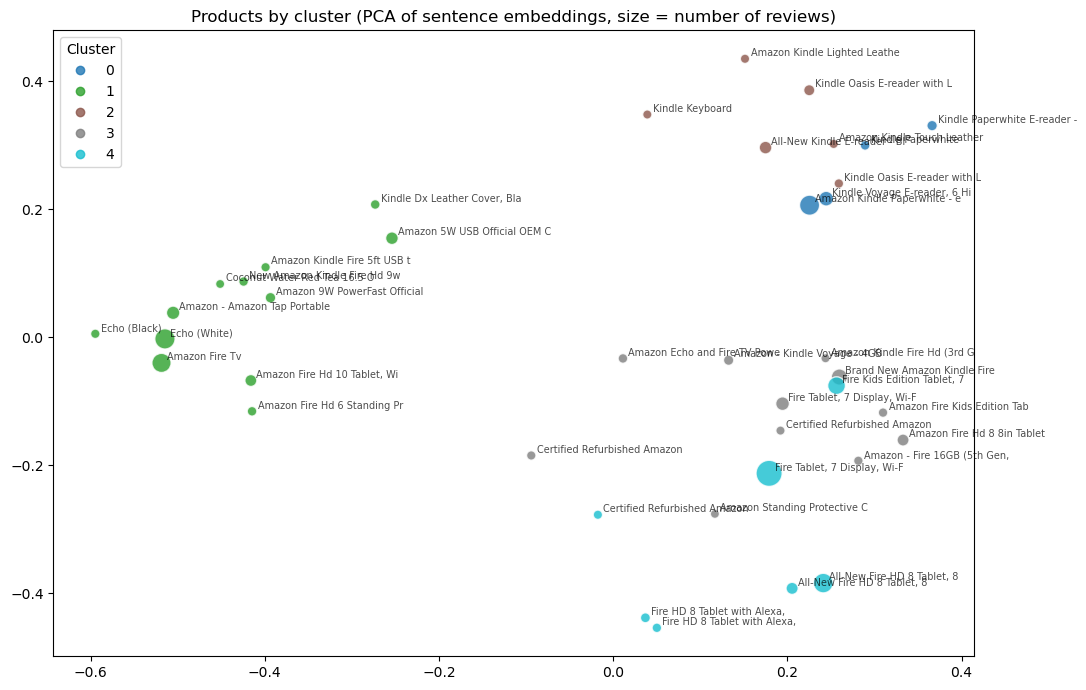

In [10]:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=products["cluster"], cmap="tab10",
                     s=40 + products["n_reviews"] ** 0.5 * 3, alpha=0.8, edgecolors="white")
for (x, y), name in zip(coords, products["product"]):
    ax.annotate(name[:28], (x, y), fontsize=7, alpha=0.7, xytext=(4, 2), textcoords="offset points")
ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.set_title("Products by cluster (PCA of sentence embeddings, size = number of reviews)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "clusters_pca.png", dpi=150)
plt.show()

## Step 9. Name the clusters
Fill in after reading Step 7. Examples of names: *Fire tablets*, *Kindle e-readers*, *Echo & smart speakers*, *Fire TV & streaming*, *Accessories (chargers, cables, cases)*.

If one cluster is clearly mixed, go back to Step 6 and try another `K`.

In [11]:
cluster_names = {c: f"Cluster {c}" for c in range(K)}   # placeholder
# cluster_names = {
#     0: "...",
#     1: "...",
# }

products["category"] = products["cluster"].map(cluster_names)
products[["product", "category", "n_reviews", "avg_rating"]].sort_values(["category", "n_reviews"], ascending=[True, False])

,product,category,n_reviews,avg_rating
17,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Cluster 0,3176,4.755038
38,"Kindle Voyage E-reader, 6 High-Resolution Disp...",Cluster 0,580,4.743103
37,"Kindle Paperwhite E-reader - White, 6 High-Res...",Cluster 0,30,4.533333
36,Kindle Paperwhite,Cluster 0,9,4.888889
26,Echo (White),Cluster 1,3308,4.645405
13,Amazon Fire Tv,Cluster 1,2527,4.650178
3,Amazon - Amazon Tap Portable Bluetooth and Wi-...,Cluster 1,318,4.729560
6,Amazon 5W USB Official OEM Charger and Power A...,Cluster 1,206,4.456311
9,"Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Specia...",Cluster 1,128,4.773438
7,Amazon 9W PowerFast Official OEM USB Charger a...,Cluster 1,36,4.694444


## Step 10. Sanity check (optional)
With only ~40 products you can write down the group *you* expect for each product and compare.
Adjusted Rand Index: 1.0 = same grouping, 0 = random.

In [12]:
from sklearn.metrics import adjusted_rand_score

expected = {
    # "Echo (Black)": "speaker",
    # "Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta": "tablet",
}

if expected:
    check = products[products["product"].isin(expected)]
    print("Products labelled by hand:", len(check))
    print("Adjusted Rand Index:", round(adjusted_rand_score(check["product"].map(expected), check["cluster"]), 3))
else:
    print("Fill `expected` to run this check.")

Fill `expected` to run this check.


## Step 11. Map back to every review and save
Task 3 reads this file.

In [13]:
display(reviews.head())
reviews["category"] = reviews["product"].map(products.set_index("product")["category"])

print("Reviews without a category:", reviews["category"].isna().sum())
display(reviews["category"].value_counts())
reviews.head()
display(reviews.head())

out_reviews = config.PROCESSED_DIR / "reviews_clustered.csv"
out_products = config.PROCESSED_DIR / "product_clusters.csv"
reviews.to_csv(out_reviews, index=False)
products.drop(columns="doc").to_csv(out_products, index=False)
print("Saved:", out_reviews.name, "and", out_products.name)

,name,categories,reviews.rating,reviews.text,reviews.title,product
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."


Reviews without a category: 0


category
Cluster 4    15630
Cluster 1     6555
Cluster 0     3795
Cluster 3     1590
Cluster 2      293
Name: count, dtype: int64

,name,categories,reviews.rating,reviews.text,reviews.title,product,category
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Cluster 4
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Cluster 4
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Cluster 4
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Cluster 4
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Cluster 4


Saved: reviews_clustered.csv and product_clusters.csv


## Findings
Write 3–5 bullets after running:
- Chosen k and why (silhouette, sizes):
- The categories and what is in each:
- Products that landed in a surprising cluster, and why:
- Limits (only ~40 products, inconsistent category tags, odd items like "Coconut Water Red Tea"):